In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion

from sklearn.cluster import (
    KMeans,
    DBSCAN,
    MeanShift,
    estimate_bandwidth,
    AgglomerativeClustering,
)
from sklearn_extra.cluster import KMedoids
from sklearn.mixture import GaussianMixture

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

from scipy.cluster.hierarchy import dendrogram

from Transformers import *  
import gower
from tqdm import tqdm
from prince import FAMD
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("data/TransformedData/train.csv") 

W przypadku KMedoids, DBScan i AgglomerativeClustering możliwe jest wykorzystanie danych mieszanych (tu: ciągłych i binarnych) wykorzystując policzoną już wcześniej macierz odległości. Wykorzystany [dystans Gowera](https://en.wikipedia.org/wiki/Gower%27s_distance), który choć nie jest metryką, sprawdza się w zadaniach klasteryzacji. Nadaje się on przy łączeniu różnych rodzajów zmiennych, dlatego sprawdzi się dobrze, w opozycji do np. metryki euklidesowej, która dla danych binarnych nie ma sensownego zastosowania.

In [3]:
df_gower = gower.gower_matrix(df)

In [24]:
df_gower

array([[0.        , 0.21624693, 0.18593518, ..., 0.15311696, 0.19469117,
        0.18327686],
       [0.21624693, 0.        , 0.12009738, ..., 0.20177728, 0.17036913,
        0.18646066],
       [0.18593518, 0.12009738, 0.        , ..., 0.20056859, 0.22778608,
        0.22864829],
       ...,
       [0.15311696, 0.20177728, 0.20056859, ..., 0.        , 0.18691961,
        0.13823666],
       [0.19469117, 0.17036913, 0.22778608, ..., 0.18691961, 0.        ,
        0.0980607 ],
       [0.18327686, 0.18646066, 0.22864829, ..., 0.13823666, 0.0980607 ,
        0.        ]], dtype=float32)

W przypadku KMeans, GMM oraz Mean Shift nie jest możliwe zastosowanie innej metryki, dlatego przed przekazaniem danych wykonamy [FAMD](https://en.wikipedia.org/wiki/Factor_analysis_of_mixed_data) - proces podobny do PCA, z tym że działa dla zmiennych o różnych typach danych (tu: ciągłe i binarne), zwracając zmienne ciągłe, co będzie odpowiednie w przypadku ww. algorytmów.

In [19]:
df_ = df.copy()
for col in df_.columns:
    if df_[col].nunique() == 2 and df_[col].dtype in ['int64', 'float64']:
        df_[col] = df_[col].astype('category')


In [55]:
n_components=21
random_state=42

famd = FAMD(n_components=n_components, random_state=random_state)
df_famd = famd.fit_transform(df_)

c:\Users\Macie\.conda\envs\ML\Lib\site-packages\prince\pca.py:175: PerformanceWarning: Concatenating sparse arrays with multiple fill values: '[-3.387215721797939, -0.16361434535170566, -3.2581259360842107, -0.9405399431259603, -2.4524792626874046, -2.3420814388249283, -3.343010940126382, -0.5694539965575123, -2.9023995924665167, -1.753874740581606, -2.9341925241370457, -1.70015123777218, -2.7864702517461515, -1.9327657737381794, -3.331890933998877, -0.6312707849537244, -3.369296440170536, -0.3845016232139378, -3.3089872905797133, -0.7420263545063125, -3.351916685433611, -0.5144458512921991, -3.3244874336724237, -0.6691661253785509, -3.385778481583962, -0.19106039265897246, -3.3747993979814908, -0.33275970817358425, -3.378403028904569, -0.29392681791295444, -3.358354054180777, -0.47059329231039604, -3.3886523524305745, -0.13051909579342663, -2.978949530054761, -1.620450461256536, -3.3600746385389635, -0.45814672698520315, -2.954545787510534, -1.6645297202224285, -3.202185860676877, -1.

In [58]:
df_famd

component,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,4.531526,-0.642407,-0.336177,-2.464849,-5.912534,-1.049904,0.516342,-2.505144,-0.626534,-0.752278,...,1.646897,-0.386741,-0.309577,1.063697,1.990852,-2.338721,-4.659780,0.957382,-2.235839,5.620616
1,-2.040690,-3.308055,1.413497,-0.007219,-1.073695,-1.490509,-0.244924,0.188806,0.041549,0.011215,...,0.302682,0.563609,-1.006881,-0.775970,2.451665,-1.661816,4.019335,0.226035,2.128646,0.716050
2,-5.871199,-0.838805,3.103379,-0.705593,-1.162202,-1.073750,0.611353,-0.948441,-0.645663,-0.286206,...,0.911707,0.213203,-1.435204,-0.489912,1.729985,-1.489162,-1.937928,-3.979039,1.738295,-0.213667
3,-3.754442,-3.167618,-0.699645,-1.569842,-0.815842,1.509247,0.038579,0.187382,-0.176491,0.080556,...,0.005307,-0.336120,1.002630,0.479919,-2.061670,0.628274,-1.752216,0.065579,3.831139,0.979420
4,6.096032,-3.831683,2.173039,-1.045895,-0.932446,1.464248,0.006142,0.411019,0.211159,0.078860,...,-0.534094,-0.675390,1.637677,0.296328,-2.538032,1.298306,1.488051,-1.883612,-1.005962,4.823778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18897,4.179822,1.637404,2.254705,-0.170281,1.572983,1.370461,-0.180668,0.916700,-0.141821,0.371881,...,-0.621144,-0.260283,0.947789,0.131780,-2.177907,1.709812,0.982381,-1.638897,-2.085847,-0.135054
18898,2.975962,-5.706787,-1.088153,-4.156548,0.135519,-1.892700,0.935968,-4.419602,-9.408906,17.098257,...,-2.879411,2.174256,-4.460610,-1.508038,1.155522,-0.048306,4.138407,-0.579412,0.624288,1.505191
18899,1.462109,4.624163,-1.797638,4.369900,-5.594208,-0.781897,0.502608,-1.701700,-1.260500,-0.732179,...,1.332409,-0.225576,-0.744196,0.887694,1.828862,-1.219990,-5.081755,0.726231,-4.111627,0.112658
18900,4.479115,-6.923569,1.981012,8.090166,2.857109,-0.835242,0.513658,-1.350579,0.283894,-0.640132,...,1.646718,0.093381,0.013048,-1.080457,0.847113,-2.229502,-0.976231,2.009332,-6.563971,4.699493


In [56]:
famd.eigenvalues_summary


,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,18.626,6.84%,6.84%
1,15.568,5.71%,12.55%
2,15.130,5.55%,18.10%
3,13.619,5.00%,23.10%
4,13.385,4.91%,28.01%
5,12.196,4.48%,32.49%
6,12.016,4.41%,36.90%
7,11.992,4.40%,41.30%
8,11.822,4.34%,45.63%


In [57]:
famd.column_contributions_.style.format('{:.0%}')


component,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
variable,,,,,,,,,,,,,,,,,,,,,
ct_scale__skew__installment_sqrt,1%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,1%,0%,0%
ct_scale__skew__total_acc_sqrt,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,1%
ct_pass__date__time_to_last_payment,1%,0%,1%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%
ct_pass__progress__loan_to_income_full_period,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%
basic_num__dti,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%
basic_num__annual_income,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%
basic_num__emp_years,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%
basic_num__sub_grade_numeric,1%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,1%,0%,1%
basic_cat__home_ownership_OTHER,0%,0%,0%,0%,0%,1%,1%,0%,0%,0%,0%,0%,0%,0%,0%,2%,3%,0%,0%,0%,0%


## TSNE

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold      import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def tsne_plot(
    X,
    y=None,                  
    perplexity=30,
    learning_rate=200,
    n_iter=1000,            
    pca_dim=None,
    random_state=42,
    figsize=(6, 5),
    cmap="tab10",            
):
    
    
    X_proc = StandardScaler().fit_transform(X)

   
    if pca_dim is not None and X_proc.shape[1] > pca_dim:
        X_proc = PCA(n_components=pca_dim, random_state=random_state)\
                 .fit_transform(X_proc)

    
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        n_iter=n_iter,
        init="random",
        random_state=random_state,
    )
    embedding = tsne.fit_transform(X_proc)

   
    plt.figure(figsize=figsize)

    if y is None:
        
        plt.scatter(embedding[:, 0], embedding[:, 1],
                    s=20, alpha=0.7, edgecolors="k", linewidths=0.3)
    else:
        
        y = np.asarray(y)
        n_classes = len(np.unique(y))
        cmap_mod  = plt.cm.get_cmap(cmap, n_classes)  

        scatter = plt.scatter(
            embedding[:, 0],
            embedding[:, 1],
            c=y,
            cmap=cmap_mod,
            s=20,
            alpha=0.8,
            edgecolors="k",
            linewidths=0.3,
        )
        handles, labels = scatter.legend_elements(prop="colors", alpha=0.8)
        plt.legend(handles, labels, title="cluster", loc="best", frameon=False)

    plt.title("t-SNE projection")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return embedding


/Users/piotrkot/Programming/PycharmProjects/UNI/UczenieMaszynowe/.venv/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


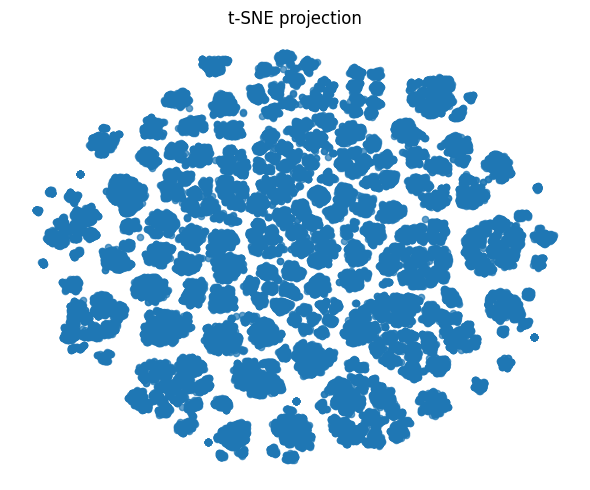

array([[ 35.958977,  11.17174 ],
       [ -9.056833,  65.14747 ],
       [  5.227085,  33.123478],
       ...,
       [-76.5386  ,  16.849934],
       [-63.880688,  12.641262],
       [-64.569786,   9.949482]], dtype=float32)

In [ ]:
#tsne_plot(df)

## AgglomerativeClustering

In [6]:
def agglomerative_quality_plot(
    X,
    X_gower,
    n_clusters_range=range(2, 11),
    linkage="average",
    metric="precomputed",
    compute_metrics=("silhouette", "davies_bouldin", "calinski_harabasz"),
):
    
    results = {m: [] for m in compute_metrics}

    print(f"{'k':^3s} | {'clusters':^8s}" +
          "".join([f" | {m.replace('_',' ').title():^18s}" for m in compute_metrics]))
    print("-" * (12 + 22 * len(compute_metrics)))

    for k in tqdm(n_clusters_range):
        
        kwargs = dict(n_clusters=k, linkage=linkage)
        
        if linkage != "ward":
            kwargs["metric"] = metric

        model = AgglomerativeClustering(**kwargs)
        labels = model.fit_predict(X_gower)

        
        for m in compute_metrics:
            if len(np.unique(labels)) <= 1:
                val = 0.0
            elif m == "silhouette":
                val = silhouette_score(X_gower, labels, metric=metric)
            elif m == "davies_bouldin":
                val = davies_bouldin_score(X, labels)
            elif m == "calinski_harabasz":
                val = calinski_harabasz_score(X, labels)
            else:
                raise ValueError(f"Nieznana metryka: {m}")
            results[m].append(val)

        
        row = f"{k:^3d} | {len(np.unique(labels)):8d}" + \
              "".join([f" | {results[m][-1]:18.4f}" for m in compute_metrics])
        print(row)

    
    colors = {"silhouette": "tab:blue",
              "davies_bouldin": "tab:red",
              "calinski_harabasz": "tab:green"}

    n_rows = len(compute_metrics)
    fig, axes = plt.subplots(n_rows, 1, figsize=(8, 3 * n_rows), sharex=True)

    if n_rows == 1:
        axes = [axes]

    for ax, m in zip(axes, compute_metrics):
        ax.plot(
            list(n_clusters_range),
            results[m],
            marker="o",
            color=colors.get(m, "black"),
            label=m.replace("_", " ").title(),
        )
        ax.set_ylabel(m.replace("_", " ").title())
        ax.grid(alpha=0.4)
        ax.legend()

    axes[-1].set_xlabel("Liczba klastrów (k)")
    plt.suptitle(
        f"Agglomerative ({linkage}, metric={metric}) – jakościowe metryki vs. liczba klastrów",
        y=0.93,
        fontsize=14,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()


 k  | clusters |     Silhouette     |   Davies Bouldin   | Calinski Harabasz 
------------------------------------------------------------------------------


100%|██████████| 1/1 [00:28<00:00, 28.49s/it]

 2  |        2 |             0.2494 |             1.6312 |             5.9214


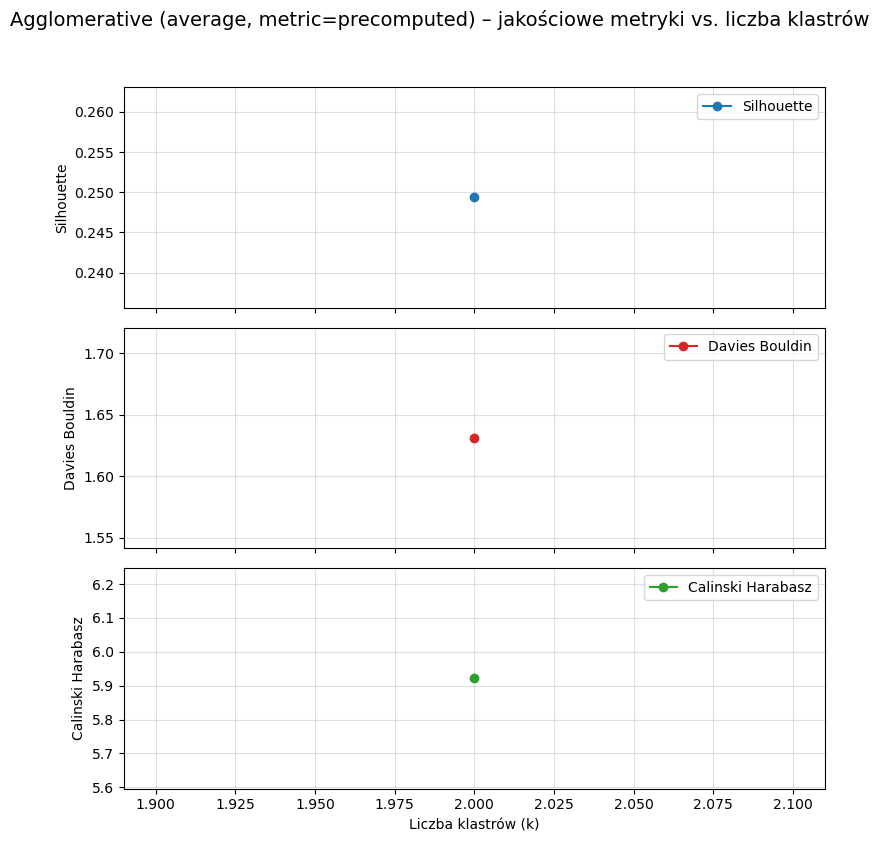

In [7]:
agglomerative_quality_plot(df, df_gower, n_clusters_range=range(2,3))

## Kmeans

In [28]:
def KMeans_plotter(X, lower_bound=2, upper_bound=20):
    if lower_bound < 2:
        raise ValueError("lower_bound must be at least 2.")
    
    inertia_list = []
    silhouette_list = []
    

    for i in range(lower_bound, upper_bound + 1):
        k = KMeans(n_clusters=i, random_state=42)
        k.fit(X)
        predicted = k.predict(X)
        inertia_list.append(k.inertia_)
        silhouette_list.append(silhouette_score(X, predicted))
    
    x_cord = np.arange(lower_bound, upper_bound + 1)
    
    
    
    fig, ax1 = plt.subplots(figsize=(8, 5))



    ax1.plot(x_cord, inertia_list, color='blue', linewidth=2, label='Inertia ')

    ax1.set_xlabel('Number of clusters (k)')
    ax1.set_ylabel('Inertia', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, linestyle='--', alpha=0.5)


    ax2 = ax1.twinx()

    ax2.plot(x_cord, silhouette_list, color='orange', linewidth=2, label='Silhouette ')

    ax2.set_ylabel('Silhouette Score', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')


    legend1 = ax1.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0))
    for text in legend1.get_texts():
        text.set_color('blue')

    legend2 = ax2.legend(loc='upper right', bbox_to_anchor=(1.0, 0.92))
    for text in legend2.get_texts():
        text.set_color('orange')

    plt.title('Inertia and Silhouette Scores vs. Number of Clusters')
    plt.tight_layout()


c:\Users\Macie\.conda\envs\ML\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Macie\.conda\envs\ML\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Macie\.conda\envs\ML\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Macie\.conda\envs\ML\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Macie\.conda\envs\ML\Lib\si

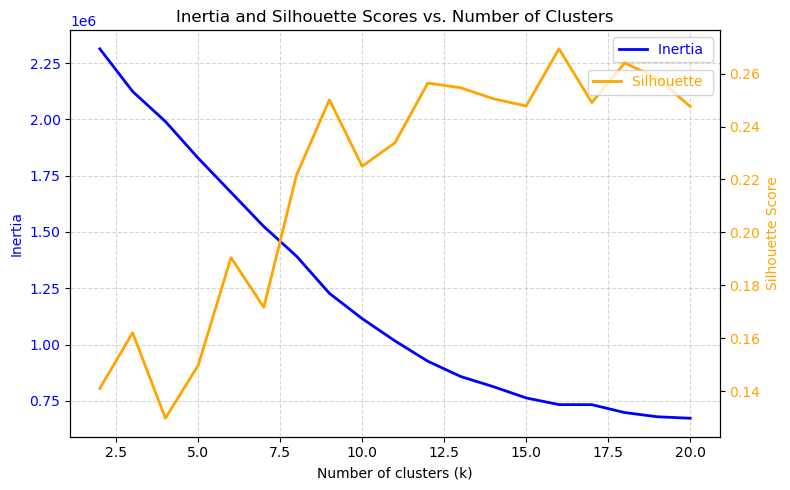

In [36]:
KMeans_plotter(df_famd)

## Kmedoids

In [10]:
def KMedoids_plotter(X_gower, lower_bound=2, upper_bound=20, metric='precomputed'):
    
    if lower_bound < 2:
        raise ValueError("lower_bound must be at least 2.")
    
    inertia_list = []
    silhouette_list = []

    
    for k in tqdm(range(lower_bound, upper_bound + 1)):
        
        kmedoids = KMedoids(
            n_clusters=k,
            metric=metric,
            random_state=42,
            method='pam'     
        )
        labels = kmedoids.fit_predict(X_gower)

        
        inertia_list.append(kmedoids.inertia_)

        
        unique_labels = np.unique(labels)
        if len(unique_labels) > 1:
            sil = silhouette_score(X_gower, labels, metric=metric)
        else:
            sil = 0.0
        silhouette_list.append(sil)

    x_cord = np.arange(lower_bound, upper_bound + 1)

   
    fig, ax1 = plt.subplots(figsize=(8, 5))

    
    ax1.plot(
        x_cord,
        inertia_list,
        color='blue',
        linewidth=2,
        marker='o',
        label='Inertia'
    )
    ax1.set_xlabel('Number of clusters (k)')
    ax1.set_ylabel('Inertia', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, linestyle='--', alpha=0.5)

    
    ax2 = ax1.twinx()
    ax2.plot(
        x_cord,
        silhouette_list,
        color='orange',
        linewidth=2,
        marker='s',
        label='Silhouette'
    )
    ax2.set_ylabel('Silhouette Score', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')

    legend1 = ax1.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0))
    for text in legend1.get_texts():
        text.set_color('blue')
    legend2 = ax2.legend(loc='upper right', bbox_to_anchor=(1.0, 0.92))
    for text in legend2.get_texts():
        text.set_color('orange')

    plt.title('Inertia and Silhouette Scores vs. Number of Clusters (KMedoids)')
    plt.tight_layout()
    plt.show()

100%|██████████| 1/1 [01:00<00:00, 60.92s/it]


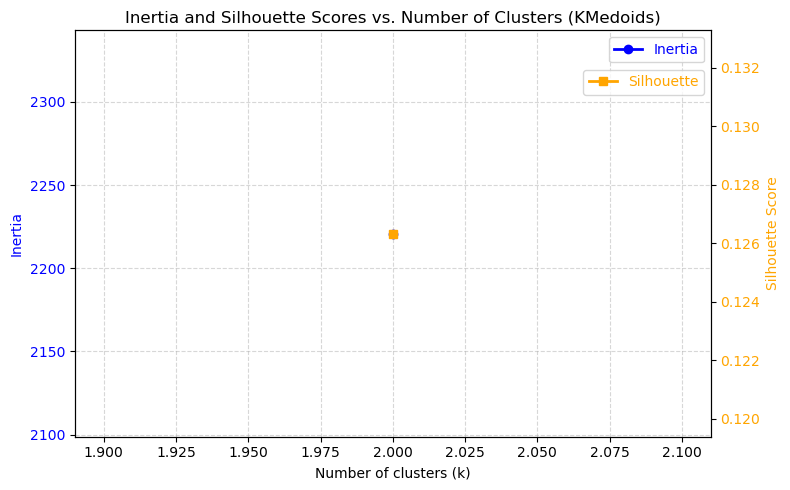

In [11]:
KMedoids_plotter(df_gower, lower_bound=2, upper_bound=2)

## DB SCAN 

In [12]:
def DBScanner(X, X_gower, params_list):

    if len(params_list) == 0:
        raise ValueError("Wow!")

    silhouette_list = []
    db_index_list = []
    ch_score_list = []

    
    for i, param in enumerate(tqdm(params_list)):
        db = DBSCAN(**param, metric = 'precomputed')
        labels = db.fit_predict(X_gower)

        
        unique_labels = set(labels)
        if len(unique_labels - {-1}) <= 1:
            print(f"param_nr_{i}: Outliers or only one cluster → metryki = 0")
            silhouette_list.append(0.0)
            db_index_list.append(0.0)
            ch_score_list.append(0.0)
        else:
           
            try:
                sil = silhouette_score(X, labels)
            except:
                sil = 0.0

            
            try:
                dbi = davies_bouldin_score(X, labels)
            except:
                dbi = 0.0

            
            try:
                chs = calinski_harabasz_score(X, labels)
            except:
                chs = 0.0

            print(f"param_nr_{i}: Silhouette = {sil:.4f}, "
                  f"Davies–Bouldin = {dbi:.4f}, "
                  f"Calinski–Harabasz = {chs:.4f}")

            silhouette_list.append(sil)
            db_index_list.append(dbi)
            ch_score_list.append(chs)


    param_labels = [f"param_nr_{i}" for i in range(len(params_list))]
    x_pos = np.arange(len(params_list))

    
    fig, axs = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

  
    axs[0].scatter(x=x_pos, y=silhouette_list, color='tab:blue', edgecolor='k', alpha=0.7)
    axs[0].plot(x_pos, silhouette_list, color='tab:blue', linewidth=2)
    axs[0].set_ylabel('Silhouette Score', color='tab:blue')
    axs[0].tick_params(axis='y', labelcolor='tab:blue')
    axs[0].grid(alpha=0.3)

    
    axs[1].scatter(x=x_pos, y=db_index_list, color='tab:red', edgecolor='k', alpha=0.7)
    axs[1].plot(x_pos, db_index_list, color='tab:red', linewidth=2)
    axs[1].set_ylabel('Davies–Bouldin Index', color='tab:red')
    axs[1].tick_params(axis='y', labelcolor='tab:red')
    axs[1].grid(alpha=0.3)

   
    axs[2].scatter(x=x_pos, y=ch_score_list, color='tab:green', edgecolor='k', alpha=0.7)
    axs[2].plot(x_pos, ch_score_list, color='tab:green', linewidth=2)
    axs[2].set_ylabel('Calinski–Harabasz Score', color='tab:green')
    axs[2].tick_params(axis='y', labelcolor='tab:green')
    axs[2].grid(alpha=0.3)
    axs[2].set_xlabel('Parameter set index')

   
    plt.xticks(ticks=x_pos, labels=param_labels, rotation=45)


    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


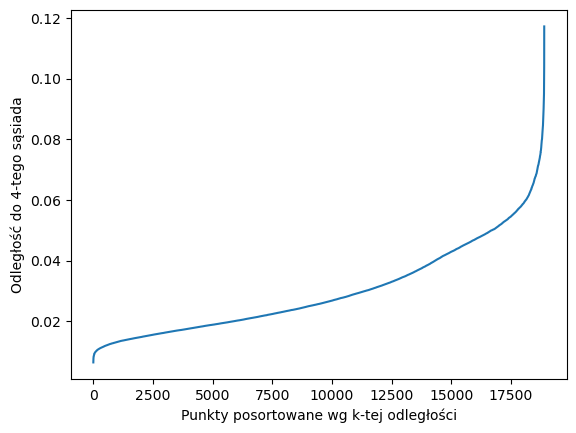

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# D - macierz odległości Gowera
k = 4  # np. min_samples = 4
distances = np.sort(np.partition(df_gower, k, axis=1)[:, k])  # odległość do k-tego sąsiada
plt.plot(distances)
plt.xlabel("Punkty posortowane wg k-tej odległości")
plt.ylabel(f"Odległość do {k}-tego sąsiada")
plt.show()


100%|██████████| 1/1 [00:08<00:00,  8.07s/it]

param_nr_0: Silhouette = -0.3829, Davies–Bouldin = 1.7559, Calinski–Harabasz = 3.5469


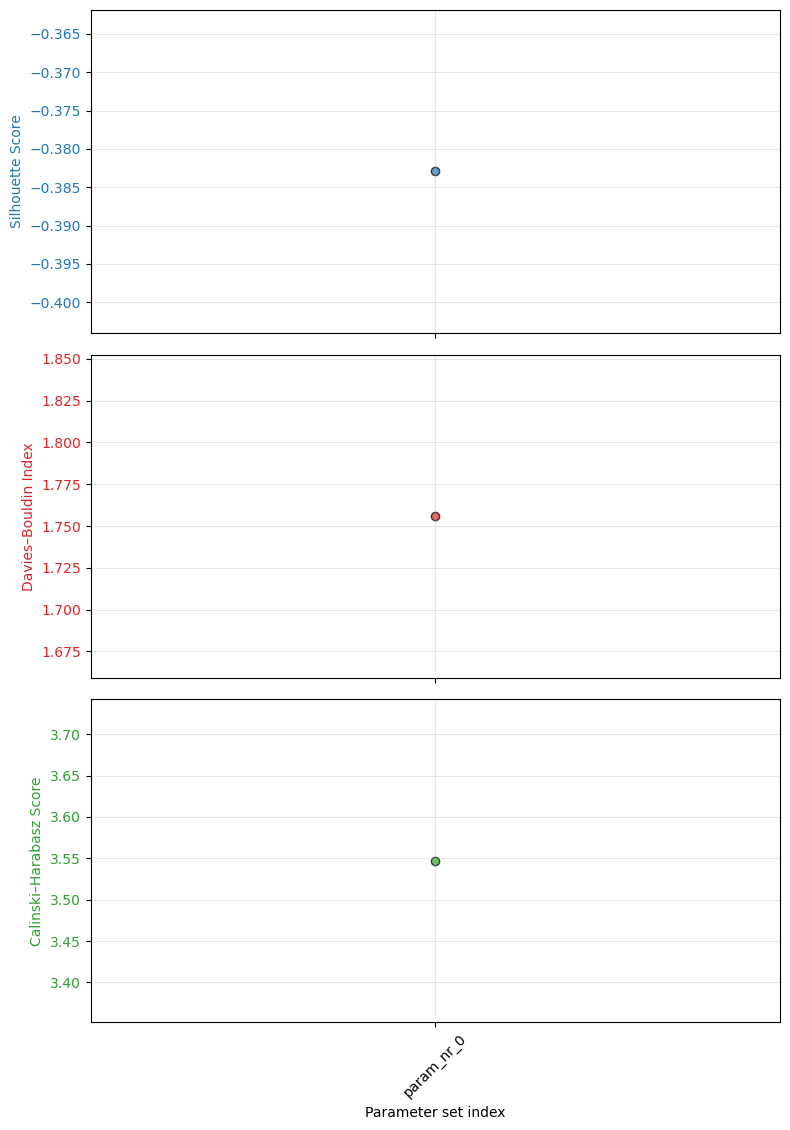

In [15]:
params_list = [dict(eps=i, min_samples=j) for i in np.arange(0.01, 0.02, 0.01) for j in [5]]
DBScanner(df, df_gower, params_list)

In [ ]:
# params_list = [
#     {"eps": 1, "min_samples": 5},
#     {"eps": 2, "min_samples": 10},
#     {"eps": 3, "min_samples": 5}, 
#     {"eps":4,"min_samples": 10},
#     {"eps":5,"min_samples":15}
# ]

## Gaussian Mixture Models 

In [31]:
def gmm_optimal_components(
    X,
    min_components=1,
    max_components=10,
    criterion='bic',
    random_state=42
):
   
    n_components_range = np.arange(min_components, max_components + 1)
    aic_values = []
    bic_values = []




    for n in n_components_range:
        
        gmm = GaussianMixture(n_components=n, random_state=random_state)
        gmm.fit(X)

     
        aic = gmm.aic(X)
        bic = gmm.bic(X)
        aic_values.append(aic)
        bic_values.append(bic)


    
    plt.figure(figsize=(8, 5))

    plt.plot(n_components_range, aic_values, marker='o', color='steelblue', label='AIC')
    plt.plot(n_components_range, bic_values, marker='s', color='salmon', label='BIC')


    plt.xticks(n_components_range)
    plt.xlabel('Liczba komponentów (n_components)')
    title = "Kryteria AIC i BIC vs. liczba komponentów (GMM)"
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

   
    if criterion.lower() == 'aic':
        best_idx = np.argmin(aic_values)
        best_n = n_components_range[best_idx]
    elif criterion.lower() == 'bic':
        best_idx = np.argmin(bic_values)
        best_n = n_components_range[best_idx]
    else:
        raise ValueError("Kryterium musi być 'aic' lub 'bic'")

    print(f"\nOptimal {criterion.upper()}: {best_n}")
    return best_n

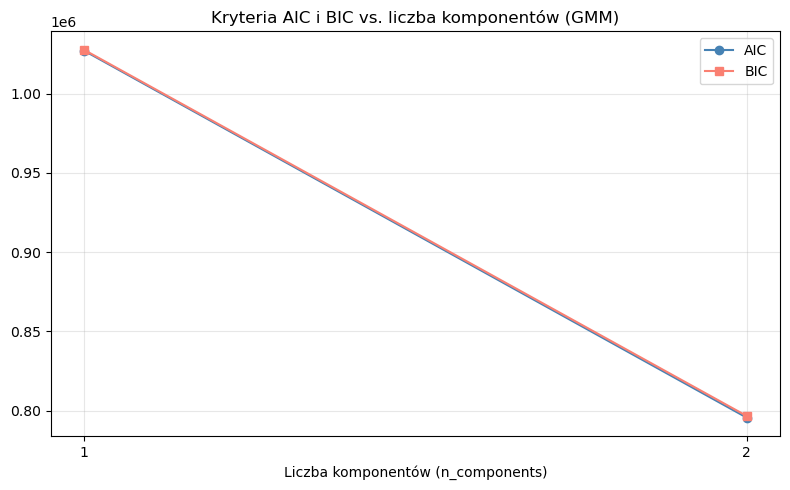


Optimal BIC: 2


2

In [32]:
gmm_optimal_components(df_famd,min_components=1,max_components=2)

## Mean shift 

In [33]:
def meanshift_quality_plot(
    X,
    bandwidth_list,
    metrics=("silhouette", "davies_bouldin", "calinski_harabasz"),
    cluster_all=True,
    n_jobs=None,
):
    
    results = {m: [] for m in metrics}
    n_clusters_list = []

    for bw in bandwidth_list:
        ms = MeanShift(bandwidth=bw, cluster_all=cluster_all, n_jobs=n_jobs)
        labels = ms.fit_predict(X)
        n_clusters = len(np.unique(labels))
        n_clusters_list.append(n_clusters)

        if n_clusters <= 1:
            for m in metrics:
                results[m].append(0.0)
            continue

        if "silhouette" in metrics:
            results["silhouette"].append(silhouette_score(X, labels))
        if "davies_bouldin" in metrics:
            results["davies_bouldin"].append(davies_bouldin_score(X, labels))
        if "calinski_harabasz" in metrics:
            results["calinski_harabasz"].append(
                calinski_harabasz_score(X, labels))

  
    n_metrics = len(metrics)
    fig, axs = plt.subplots(
        n_metrics, 1, figsize=(8, 3 * n_metrics), sharex=True
    )

    if n_metrics == 1:
        axs = [axs]  

    colors = {
        "silhouette": "tab:blue",
        "davies_bouldin": "tab:red",
        "calinski_harabasz": "tab:green",
    }
    for ax, m in zip(axs, metrics):
        ax.plot(
            bandwidth_list,
            results[m],
            marker="o",
            color=colors.get(m, "black"),
            label=m.replace("_", " ").title(),
        )
        ax.set_ylabel(m.replace("_", " ").title())
        ax.grid(alpha=0.4)
        ax.legend()

    axs[-1].set_xlabel("Bandwidth")
    plt.suptitle("Miary jakości klasteryzacji vs. bandwidth", y=0.94)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

    header = "bandwidth | n_clusters " + " ".join(f"| {m:^18s}" for m in metrics)
    print(header)
    print("-" * len(header))
    for i, bw in enumerate(bandwidth_list):
        row = f"{bw:9.3f} | {n_clusters_list[i]:10d} "
        for m in metrics:
            row += f"| {results[m][i]:18.4f} "
        print(row)


In [35]:
bw_est = estimate_bandwidth(df_famd, quantile=0.2, n_samples=300)
bw_values = np.linspace(bw_est * 0.5, bw_est * 1.5, 8)

meanshift_quality_plot(
        df_famd,
        bandwidth_list=bw_values,
        metrics=("silhouette", "davies_bouldin", "calinski_harabasz"),
    )

KeyboardInterrupt: 